# 06 - Model Testing & Statistical Evaluation

This notebook performs a more rigorous, final evaluation of the two candidate models
shortlisted in `04_classical_ml.ipynb` and `05_deep_learning.ipynb`:

- **Classical ML**: Histogram (grayscale) + SVM
- **Deep Learning**: ResNet18 (fine-tuned)

The train/validation/test split uses the exact same seed and procedure as the previous
notebooks, so the numbers here are directly comparable.

### What this notebook adds on top of 04 / 05

- ROC curve + AUC and Precision-Recall curve + Average Precision (not computed before).
- Bootstrap confidence intervals for test Accuracy / F1 (quantifies how much we should
  trust a single point estimate on a relatively small test set).
- Stratified K-Fold cross-validation for the classical model (checks that performance is
  stable across different splits, not just the one split we happened to use).
- Validation **loss** tracked during ResNet18 training (notebook 05 only tracked
  validation accuracy/F1), so train loss vs. validation loss can be plotted side by side
  — the standard diagnostic for overfitting.
- Both models are saved to `../models/` so `07_error_analysis.ipynb` (and later `src/`
  deployment code) can load them directly instead of retraining.

### Goals

- Confirm (with more evidence) whether either model overfits.
- Produce artifacts (saved models, metrics table) for the next notebook and for model
  selection.

## 1. Imports

In [1]:
import sys
import time
import random
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

# Add project root so `src` can be imported
sys.path.append(str(Path.cwd().parent))

from src.features.histogram import extract_histogram

## 2. Reproducibility, Device, and Paths

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
DATA_DIR = Path("../data/raw/casting_data/casting_data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = Path("../results/metrics")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
VAL_RATIO = 0.2

print("Train dir:", TRAIN_DIR)
print("Test dir :", TEST_DIR)
print("Models will be saved to:", MODELS_DIR.resolve())

Train dir: ..\data\raw\casting_data\casting_data\train
Test dir : ..\data\raw\casting_data\casting_data\test
Models will be saved to: D:\Casting Quality Inspection\models


## 3. Rebuild the Train / Validation / Test Split

Identical procedure (same seed, same `torch.randperm`) as `02_check_data_pipeline.ipynb`,
`04_classical_ml.ipynb`, and `05_deep_learning.ipynb`, so results stay comparable.

In [4]:
base_train_data = datasets.ImageFolder(TRAIN_DIR)
base_test_data = datasets.ImageFolder(TEST_DIR)

print("Classes:", base_train_data.classes)
print("Class mapping:", base_train_data.class_to_idx)

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(base_train_data), generator=generator).tolist()

val_size = int(len(indices) * VAL_RATIO)
val_indices = indices[:val_size]
train_indices = indices[val_size:]

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Test images:", len(base_test_data))

Classes: ['def_front', 'ok_front']
Class mapping: {'def_front': 0, 'ok_front': 1}
Training images: 5307
Validation images: 1326
Test images: 715


## 4. Reusable Evaluation Helpers

`bootstrap_ci` estimates a 95% confidence interval for a metric by resampling the test
set with replacement many times. This tells us how much the reported test score could
plausibly vary just from which 715 images happened to end up in the test set.

In [5]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=2000, seed=SEED):
    """Bootstrap a 95% confidence interval for a given metric."""

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    rng = np.random.default_rng(seed)
    scores = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        scores[i] = metric_fn(y_true[idx], y_pred[idx])

    point = metric_fn(y_true, y_pred)
    lower, upper = np.percentile(scores, [2.5, 97.5])

    return {
        "point": point,
        "ci_low": lower,
        "ci_high": upper,
        "std": scores.std(),
    }


def plot_roc_pr(y_true, y_score, title, ax_roc, ax_pr, pos_label=1):
    """Plot ROC and PR curves for the class identified by `pos_label`.

    IMPORTANT: `y_score` must be monotonically increasing with the model's
    confidence in `pos_label` specifically. The two models in this notebook
    produce scores with different natural orientations:

    - The classical SVM's `decision_function` increases with confidence in
      class 1 ("ok_front") by scikit-learn's convention, so it is used here
      with the default `pos_label=1`.
    - ResNet18's stored score is `P(def_front)` (probability of class 0), so
      it must be called with `pos_label=0` below - otherwise scikit-learn
      silently scores it against class 1 while the values point the other
      way, producing an inverted (near-zero AUC) curve.
    """

    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=pos_label)
    roc_auc = auc(fpr, tpr)

    ax_roc.plot(fpr, tpr, label=f"{title} (AUC = {roc_auc:.4f})")
    ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title("ROC Curve")
    ax_roc.legend()

    precision, recall, _ = precision_recall_curve(y_true, y_score, pos_label=pos_label)
    ap = average_precision_score(y_true, y_score, pos_label=pos_label)

    ax_pr.plot(recall, precision, label=f"{title} (AP = {ap:.4f})")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title("Precision-Recall Curve")
    ax_pr.legend()

    return roc_auc, ap

# Part A — Classical ML: Histogram + SVM

This reproduces the best classical configuration found in `04_classical_ml.ipynb`.

## 5. Feature Extraction (Grayscale Histogram)

In [6]:
def load_image(path):
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.resize(image, (IMG_SIZE, IMG_SIZE))


def build_feature_matrix(paths, extractor):
    features = []
    for path in tqdm(paths):
        image = load_image(path)
        features.append(extractor(image))
    return np.asarray(features, dtype=np.float32)


all_paths = [Path(p) for p, _ in base_train_data.samples]
all_labels = [label for _, label in base_train_data.samples]

train_paths = [all_paths[i] for i in train_indices]
val_paths = [all_paths[i] for i in val_indices]

train_labels = [all_labels[i] for i in train_indices]
val_labels = [all_labels[i] for i in val_indices]

test_paths = [Path(p) for p, _ in base_test_data.samples]
test_labels = [label for _, label in base_test_data.samples]

print("Train:", len(train_paths), "Val:", len(val_paths), "Test:", len(test_paths))

Train: 5307 Val: 1326 Test: 715


In [7]:
X_train = build_feature_matrix(train_paths, extract_histogram)
X_val = build_feature_matrix(val_paths, extract_histogram)
X_test = build_feature_matrix(test_paths, extract_histogram)

print("Train shape:", X_train.shape)
print("Val shape  :", X_val.shape)
print("Test shape :", X_test.shape)

100%|██████████| 715/715 [00:00<00:00, 1413.34it/s]

Train shape: (5307, 256)
Val shape  : (1326, 256)
Test shape : (715, 256)


## 6. Stratified K-Fold Cross-Validation

Instead of trusting a single 80/20 split, we run 5-fold stratified cross-validation on
the training data. If accuracy/F1 stay tight (low std) across folds, that is stronger
evidence the model is not just lucky on one particular split.

In [8]:
def make_classical_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=SEED)),
    ])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = cross_validate(
    make_classical_pipeline(),
    X_train,
    train_labels,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    metric: [cv_results[f"test_{metric}"].mean(), cv_results[f"test_{metric}"].std()]
    for metric in ["accuracy", "precision", "recall", "f1"]
}, index=["mean", "std"]).T

cv_summary

,mean,std
accuracy,0.996985,0.001828
precision,0.993083,0.004154
recall,1.000000,0.000000
f1,0.996525,0.002097


## 7. Train Final Classical Model

Trained on train + validation combined (same approach as notebook 04's final test
evaluation), then evaluated once on the held-out test set.

In [9]:
X_train_final = np.concatenate([X_train, X_val], axis=0)
y_train_final = np.concatenate([train_labels, val_labels], axis=0)

classical_model = make_classical_pipeline()
classical_model.fit(X_train_final, y_train_final)

train_predictions = classical_model.predict(X_train_final)
test_predictions = classical_model.predict(X_test)

train_accuracy_classical = accuracy_score(y_train_final, train_predictions)
test_accuracy_classical = accuracy_score(test_labels, test_predictions)

print(f"Train accuracy (train+val): {train_accuracy_classical:.4f}")
print(f"Test accuracy             : {test_accuracy_classical:.4f}")

Train accuracy (train+val): 0.9976
Test accuracy             : 0.9986


In [10]:
print(classification_report(test_labels, test_predictions, target_names=base_test_data.classes, digits=4))

cm_classical = confusion_matrix(test_labels, test_predictions)
print("Confusion matrix:")
print(cm_classical)

              precision    recall  f1-score   support

   def_front     0.9978    1.0000    0.9989       453
    ok_front     1.0000    0.9962    0.9981       262

    accuracy                         0.9986       715
   macro avg     0.9989    0.9981    0.9985       715
weighted avg     0.9986    0.9986    0.9986       715

Confusion matrix:
[[453   0]
 [  1 261]]


## 8. ROC / PR Curve and Bootstrap Confidence Interval (Classical)

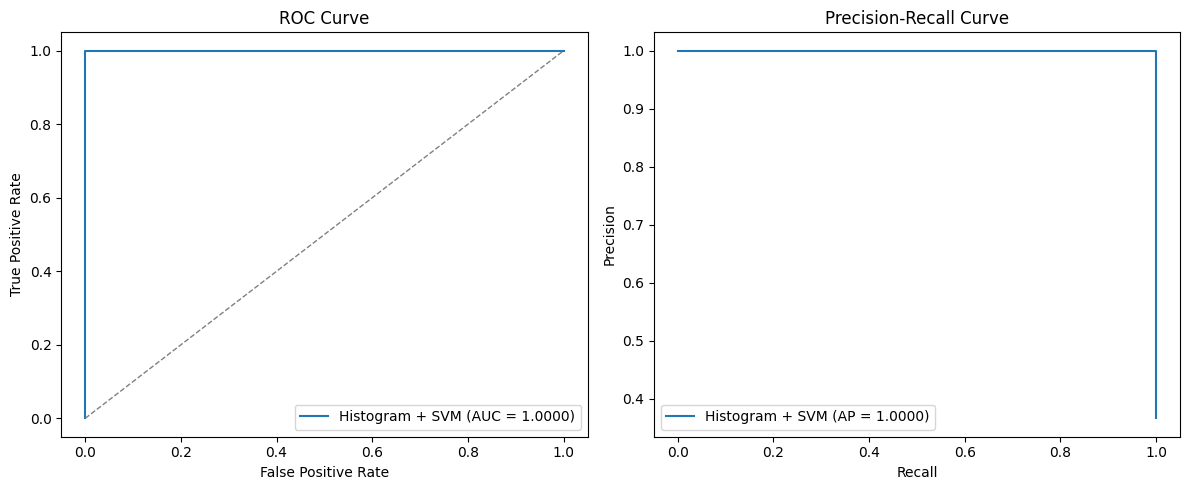

Test ROC AUC: 1.0000
Test Average Precision: 1.0000


In [11]:
# decision_function gives a continuous score suitable for ROC/PR curves without
# needing the more expensive probability=True calibration. For this SVC,
# decision_function increases with confidence in class 1 ("ok_front"), so
# pos_label=1 (the default) is the correct orientation here.
test_scores_classical = classical_model.decision_function(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
roc_auc_classical, ap_classical = plot_roc_pr(
    test_labels, test_scores_classical, "Histogram + SVM", axes[0], axes[1], pos_label=1
)
plt.tight_layout()
plt.show()

print(f"Test ROC AUC: {roc_auc_classical:.4f}")
print(f"Test Average Precision: {ap_classical:.4f}")

In [12]:
acc_ci_classical = bootstrap_ci(test_labels, test_predictions, accuracy_score)
f1_ci_classical = bootstrap_ci(test_labels, test_predictions, lambda a, b: f1_score(a, b))

print(
    f"Test Accuracy: {acc_ci_classical['point']:.4f} "
    f"(95% CI: {acc_ci_classical['ci_low']:.4f} - {acc_ci_classical['ci_high']:.4f})"
)
print(
    f"Test F1      : {f1_ci_classical['point']:.4f} "
    f"(95% CI: {f1_ci_classical['ci_low']:.4f} - {f1_ci_classical['ci_high']:.4f})"
)

Test Accuracy: 0.9986 (95% CI: 0.9958 - 1.0000)
Test F1      : 0.9981 (95% CI: 0.9937 - 1.0000)


## 9. Save the Classical Model

In [13]:
classical_model_path = MODELS_DIR / "classical_histogram_svm.joblib"
joblib.dump(classical_model, classical_model_path)
print("Saved classical model to:", classical_model_path.resolve())

Saved classical model to: D:\Casting Quality Inspection\models\classical_histogram_svm.joblib


# Part B — Deep Learning: ResNet18

Same architecture, hyperparameters, and split as `05_deep_learning.ipynb`, but the
training loop now also tracks **validation loss** (not only validation accuracy/F1) so
we can plot train loss vs. validation loss directly — the standard way to visually
diagnose overfitting.

## 10. Transforms, Datasets, and DataLoaders

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_data_dl = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_data_dl = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
test_data_dl = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

train_dataset = Subset(train_data_dl, train_indices)
val_dataset = Subset(val_data_dl, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data_dl, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 166
Val batches  : 42
Test batches : 23


## 11. Training / Evaluation Functions (with validation loss)

In [15]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate_model(model, loader, criterion=None):
    model.eval()

    all_labels = []
    all_predictions = []
    all_scores = []
    total_loss = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            if criterion is not None:
                loss = criterion(outputs, labels.to(device))
                total_loss += loss.item() * images.size(0)
                total += labels.size(0)

            probabilities = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())
            # Probability of class 0 (def_front) as the positive class score,
            # matching the classical model's label convention.
            all_scores.extend(probabilities[:, 0].cpu().numpy())

    result = {
        "accuracy": accuracy_score(all_labels, all_predictions),
        "precision": precision_score(all_labels, all_predictions, average="macro", zero_division=0),
        "recall": recall_score(all_labels, all_predictions, average="macro", zero_division=0),
        "f1": f1_score(all_labels, all_predictions, average="macro", zero_division=0),
        "labels": all_labels,
        "predictions": all_predictions,
        "scores": all_scores,
    }

    if criterion is not None:
        result["loss"] = total_loss / total

    return result


def train_model(model, model_name, epochs=10, learning_rate=0.0001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [], "train_accuracy": [],
        "val_loss": [], "val_accuracy": [], "val_f1": [],
    }

    best_f1 = -1
    best_state = None

    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer)
        val_result = evaluate_model(model, val_loader, criterion=criterion)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_result["loss"])
        history["val_accuracy"].append(val_result["accuracy"])
        history["val_f1"].append(val_result["f1"])

        print(
            f"{model_name} | Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_result['loss']:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_result['accuracy']:.4f} | "
            f"Val F1: {val_result['f1']:.4f}"
        )

        if val_result["f1"] > best_f1:
            best_f1 = val_result["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    print()
    print("Best validation F1:", round(best_f1, 4))

    return model, history

## 12. Train ResNet18

In [16]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet18.fc = nn.Linear(resnet18.fc.in_features, 2)
resnet18 = resnet18.to(device)

start = time.time()
resnet18, history_resnet18 = train_model(resnet18, model_name="ResNet18", epochs=10, learning_rate=0.0001)
print(f"Training time: {time.time() - start:.1f}s")

ResNet18 | Epoch 1/10 | Train Loss: 0.0783 | Val Loss: 0.0147 | Train Acc: 0.9727 | Val Acc: 0.9970 | Val F1: 0.9969
ResNet18 | Epoch 2/10 | Train Loss: 0.0225 | Val Loss: 0.0091 | Train Acc: 0.9942 | Val Acc: 0.9977 | Val F1: 0.9977
ResNet18 | Epoch 3/10 | Train Loss: 0.0149 | Val Loss: 0.0185 | Train Acc: 0.9949 | Val Acc: 0.9947 | Val F1: 0.9946
ResNet18 | Epoch 4/10 | Train Loss: 0.0156 | Val Loss: 0.0107 | Train Acc: 0.9949 | Val Acc: 0.9977 | Val F1: 0.9977
ResNet18 | Epoch 5/10 | Train Loss: 0.0144 | Val Loss: 0.0128 | Train Acc: 0.9953 | Val Acc: 0.9962 | Val F1: 0.9962
ResNet18 | Epoch 6/10 | Train Loss: 0.0097 | Val Loss: 0.0083 | Train Acc: 0.9972 | Val Acc: 0.9985 | Val F1: 0.9985
ResNet18 | Epoch 7/10 | Train Loss: 0.0095 | Val Loss: 0.0605 | Train Acc: 0.9964 | Val Acc: 0.9789 | Val F1: 0.9785
ResNet18 | Epoch 8/10 | Train Loss: 0.0100 | Val Loss: 0.0104 | Train Acc: 0.9968 | Val Acc: 0.9977 | Val F1: 0.9977
ResNet18 | Epoch 9/10 | Train Loss: 0.0092 | Val Loss: 0.0210 | 

## 13. Train Loss vs. Validation Loss (Overfitting Diagnostic)

If the model were overfitting, we would expect train loss to keep decreasing while
validation loss flattens out or starts rising. If both curves track each other closely,
that is direct evidence against overfitting.

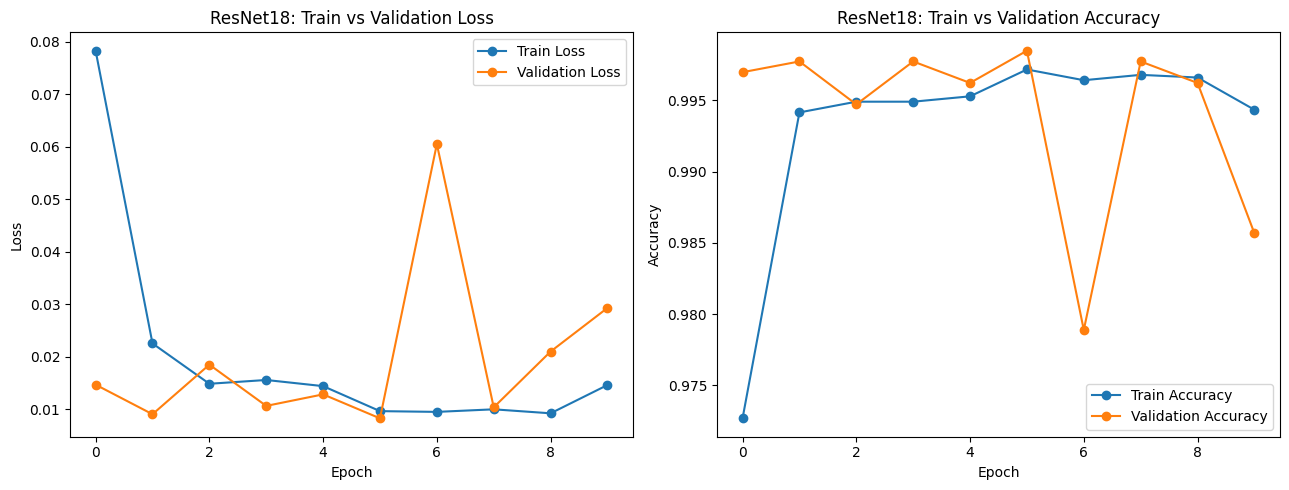

Final epoch train-val accuracy gap: 0.0087


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_resnet18["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history_resnet18["val_loss"], label="Validation Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("ResNet18: Train vs Validation Loss")
axes[0].legend()

axes[1].plot(history_resnet18["train_accuracy"], label="Train Accuracy", marker="o")
axes[1].plot(history_resnet18["val_accuracy"], label="Validation Accuracy", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("ResNet18: Train vs Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

final_gap = history_resnet18["train_accuracy"][-1] - history_resnet18["val_accuracy"][-1]
print(f"Final epoch train-val accuracy gap: {final_gap:.4f}")

## 14. Final Test Evaluation (ResNet18)

In [18]:
criterion = nn.CrossEntropyLoss()
test_result_dl = evaluate_model(resnet18, test_loader, criterion=criterion)

print(classification_report(
    test_result_dl["labels"], test_result_dl["predictions"],
    target_names=test_data_dl.classes, digits=4, zero_division=0,
))

cm_dl = confusion_matrix(test_result_dl["labels"], test_result_dl["predictions"])
print("Confusion matrix:")
print(cm_dl)

              precision    recall  f1-score   support

   def_front     1.0000    0.9978    0.9989       453
    ok_front     0.9962    1.0000    0.9981       262

    accuracy                         0.9986       715
   macro avg     0.9981    0.9989    0.9985       715
weighted avg     0.9986    0.9986    0.9986       715

Confusion matrix:
[[452   1]
 [  0 262]]


## 15. ROC / PR Curve and Bootstrap Confidence Interval (ResNet18)

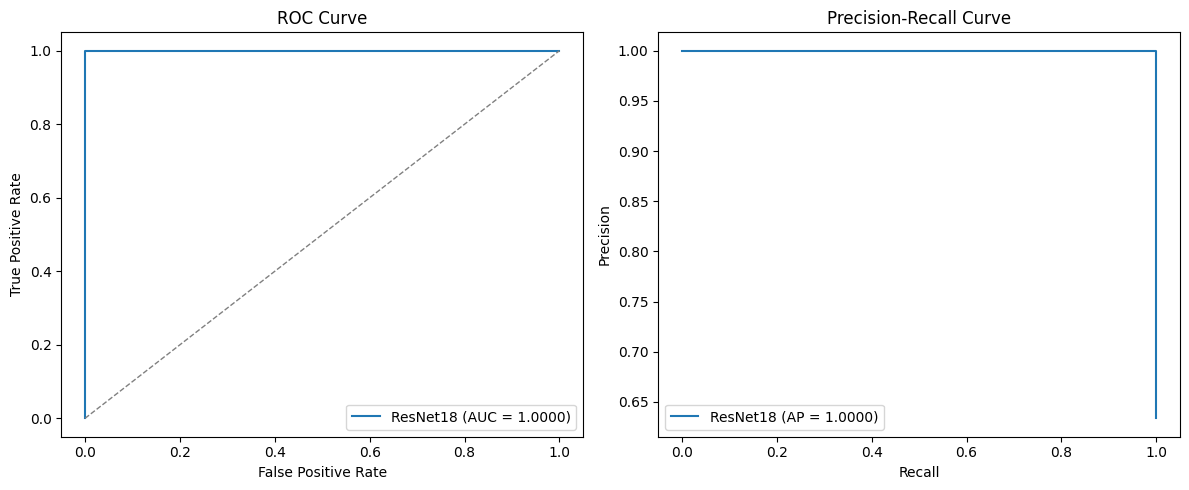

Test ROC AUC: 1.0000
Test Average Precision: 1.0000


In [19]:
# NOTE: test_result_dl["scores"] holds P(def_front) (probability of class 0),
# so pos_label=0 must be passed explicitly here - the scikit-learn default
# (pos_label=1) would silently score this against the wrong class and
# produce an inverted, near-zero AUC even though the model itself is fine.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
roc_auc_dl, ap_dl = plot_roc_pr(
    test_result_dl["labels"], test_result_dl["scores"], "ResNet18", axes[0], axes[1], pos_label=0
)
plt.tight_layout()
plt.show()

print(f"Test ROC AUC: {roc_auc_dl:.4f}")
print(f"Test Average Precision: {ap_dl:.4f}")

In [20]:
acc_ci_dl = bootstrap_ci(test_result_dl["labels"], test_result_dl["predictions"], accuracy_score)
f1_ci_dl = bootstrap_ci(test_result_dl["labels"], test_result_dl["predictions"], lambda a, b: f1_score(a, b, average="macro"))

print(
    f"Test Accuracy: {acc_ci_dl['point']:.4f} "
    f"(95% CI: {acc_ci_dl['ci_low']:.4f} - {acc_ci_dl['ci_high']:.4f})"
)
print(
    f"Test F1      : {f1_ci_dl['point']:.4f} "
    f"(95% CI: {f1_ci_dl['ci_low']:.4f} - {f1_ci_dl['ci_high']:.4f})"
)

Test Accuracy: 0.9986 (95% CI: 0.9958 - 1.0000)
Test F1      : 0.9985 (95% CI: 0.9953 - 1.0000)


## 16. Save the ResNet18 Model

In [21]:
resnet18_path = MODELS_DIR / "resnet18_casting.pt"
torch.save(resnet18.state_dict(), resnet18_path)
print("Saved ResNet18 weights to:", resnet18_path.resolve())

Saved ResNet18 weights to: D:\Casting Quality Inspection\models\resnet18_casting.pt


# Part C — Unified Comparison

In [22]:
comparison_table = pd.DataFrame([
    {
        "Model": "Histogram + SVM",
        "CV Accuracy (mean)": cv_summary.loc["accuracy", "mean"],
        "CV Accuracy (std)": cv_summary.loc["accuracy", "std"],
        "Train Accuracy": train_accuracy_classical,
        "Test Accuracy": acc_ci_classical["point"],
        "Test Accuracy 95% CI": f"[{acc_ci_classical['ci_low']:.4f}, {acc_ci_classical['ci_high']:.4f}]",
        "Test F1": f1_ci_classical["point"],
        "Test ROC AUC": roc_auc_classical,
    },
    {
        "Model": "ResNet18",
        "CV Accuracy (mean)": np.nan,
        "CV Accuracy (std)": np.nan,
        "Train Accuracy": history_resnet18["train_accuracy"][-1],
        "Test Accuracy": acc_ci_dl["point"],
        "Test Accuracy 95% CI": f"[{acc_ci_dl['ci_low']:.4f}, {acc_ci_dl['ci_high']:.4f}]",
        "Test F1": f1_ci_dl["point"],
        "Test ROC AUC": roc_auc_dl,
    },
])

comparison_table

,Model,CV Accuracy (mean),CV Accuracy (std),Train Accuracy,Test Accuracy,Test Accuracy 95% CI,Test F1,Test ROC AUC
0,Histogram + SVM,0.996985,0.001828,0.997588,0.998601,"[0.9958, 1.0000]",0.998088,1.0
1,ResNet18,NaN,NaN,0.994347,0.998601,"[0.9958, 1.0000]",0.998495,1.0


In [23]:
comparison_table.to_csv(RESULTS_DIR / "model_testing_results.csv", index=False)
print("Saved comparison table to:", (RESULTS_DIR / "model_testing_results.csv").resolve())

Saved comparison table to: D:\Casting Quality Inspection\results\metrics\model_testing_results.csv


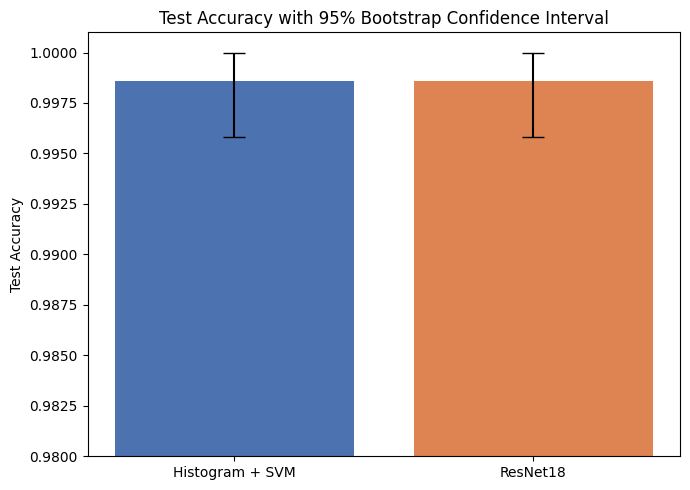

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(2)
test_acc = [acc_ci_classical["point"], acc_ci_dl["point"]]
errors = [
    [acc_ci_classical["point"] - acc_ci_classical["ci_low"], acc_ci_dl["point"] - acc_ci_dl["ci_low"]],
    [acc_ci_classical["ci_high"] - acc_ci_classical["point"], acc_ci_dl["ci_high"] - acc_ci_dl["point"]],
]

ax.bar(x, test_acc, yerr=errors, capsize=8, color=["#4C72B0", "#DD8452"])
ax.set_xticks(x)
ax.set_xticklabels(["Histogram + SVM", "ResNet18"])
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0.98, 1.001)
ax.set_title("Test Accuracy with 95% Bootstrap Confidence Interval")

plt.tight_layout()
plt.show()

## 17. Summary

- Both models were retrained using the exact split used in notebooks 04 and 05, so the
  results here are directly comparable to the earlier notebooks.
- 5-fold cross-validation on the classical model's training data shows how stable the
  Histogram + SVM performance is across different splits (see the CV mean/std table in
  section 6) — a tighter check than the single validation split used originally.
- The train-loss-vs-validation-loss plot for ResNet18 (section 13) is the direct
  overfitting diagnostic that was missing from `05_deep_learning.ipynb`.
- Bootstrap 95% confidence intervals put an honest error bar on the test accuracy/F1
  numbers, given the test set only has 715 images.
- Both trained models are saved to `../models/` for reuse in `07_error_analysis.ipynb`.

### Next step

`07_error_analysis.ipynb` investigates **why** both models reach ~99.8-99.9% accuracy.
In particular, it uses Grad-CAM to visualize which pixels ResNet18 relies on when it
predicts a part is defective, and runs statistical / robustness checks for whether
models might be exploiting global brightness differences rather than genuine defect
patterns.